In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"../main_code/2d/limited_aperture")
sys.path.append(r"../main_code/2d")
import generate_data2,grid_cell,adaptive_int_fix,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main_fix
CUDA_LAUNCH_BLOCKING=0
cupy_device=0
def single_S(y,x_left,x_right,y_below,y_upper,center,r): #单个源
    return np.exp(-300*((y[:,0]-center[0])**2+(y[:,1]-center[1])**2))

def ana_S(y,x_left,x_right,y_below,y_upper,center,r): #总源
    S_1= single_S(y,x_left,x_right,y_below,y_upper,center[0],r)
    S_2= single_S(y,x_left,x_right,y_below,y_upper,center[1],r)
    S_3= single_S(y,x_left,x_right,y_below,y_upper,center[2],r)
    S_4= single_S(y,x_left,x_right,y_below,y_upper,center[3],r)
    return S_1+S_2+S_3+S_4



cuda:0


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/_environment.py:541: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


## 1

In [2]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  #x方向网格点
nx,ny=3,3  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89,93,97,101]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=-0.3,0.3,-0.3,0.3
# b_x_min,b_x_max,b_y_min,b_y_max=-0.55,0.55,-0.55,0.55 #边界gamma处

num_batches_gauss=1
b_n=97
points_b=mea_2D.p_b_circle(alpha=1,radius=0.5,n=b_n,temp=True) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.06
center_true=np.array([[0.15,0.15],[-0.15,0.15],[-0.15,-0.15],[0.15,-0.15]]) #四个源的中心
number_gene=200
eps=0.01
batch_number_rec_mea,mea=2,1


S_int_true1, F_mea_b1, F_mea_db1= generate_data2.boundary_data_rec(kk, number_gene, points_b, ana_S,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,eps,mea,batch_number_rec_mea,device,cupy_device)
F_1=org_m.F(F_mea_b1,F_mea_db1)

cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
R_m=20


In [9]:
M=3200
af="sin"   #先用tanh
R_m=20
models0 = net_2D_fix2.pre_define(Nx,Ny,M,R_m,"sin",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],device)

/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


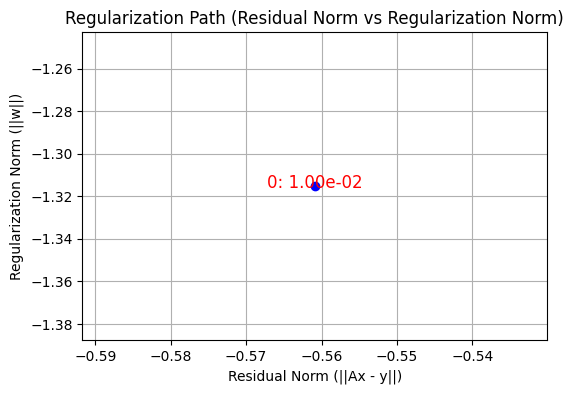

第 0 次迭代的train误差：
S_l_inf= 0.9217208429762942 S_L_2= 0.09409096515125145 S_l_2= 0.3219841645667189
第 0 次迭代的泛化误差：


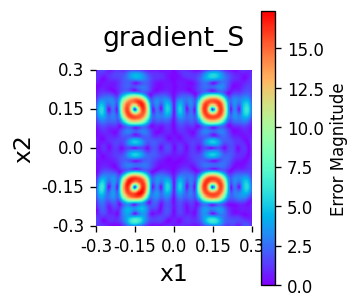

S_l_inf= 1.3338041479453842 S_L_2= 0.1120060184525085 S_l_2= 0.4659163862798143


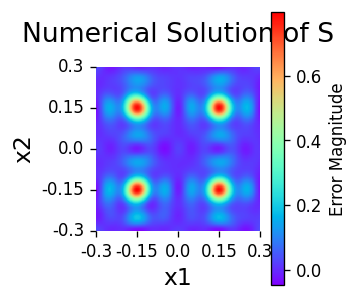

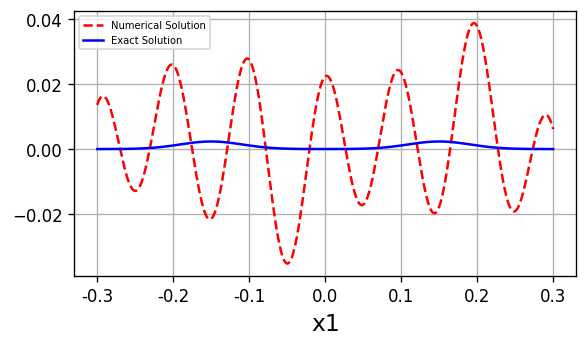

第 0 次自适应网格细分...
S_l_inf= 0.9217208429762942 S_L_2= 0.09409096515125145 S_l_2= 0.3219841645667189
S_l_inf= 1.2481760768609578 S_L_2= 0.10605585430717648 S_l_2= 0.43167319319875935
Generating visualizations...
1. Plotting mesh comparison...


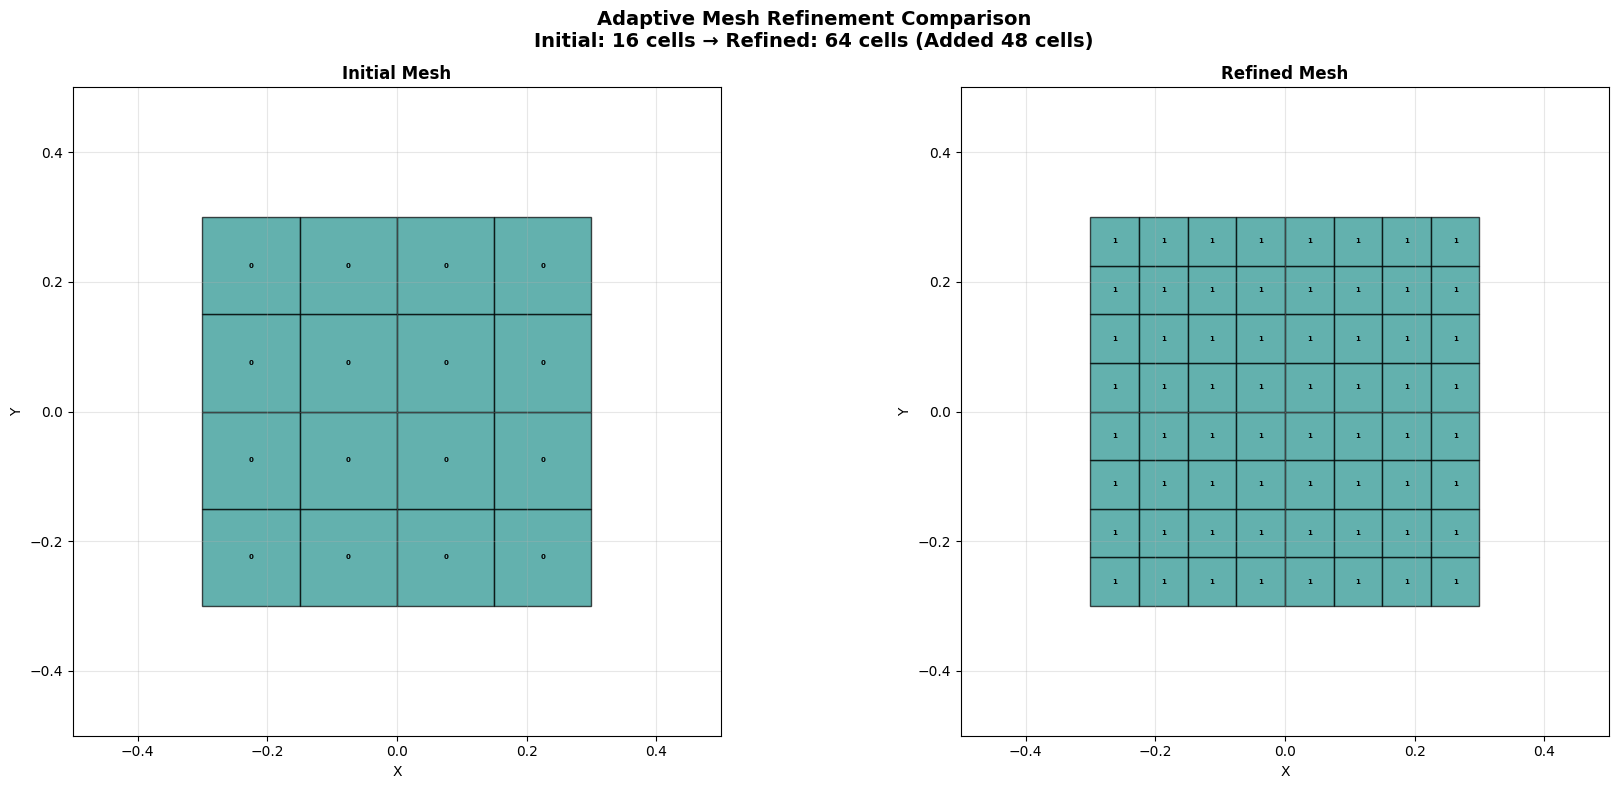

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


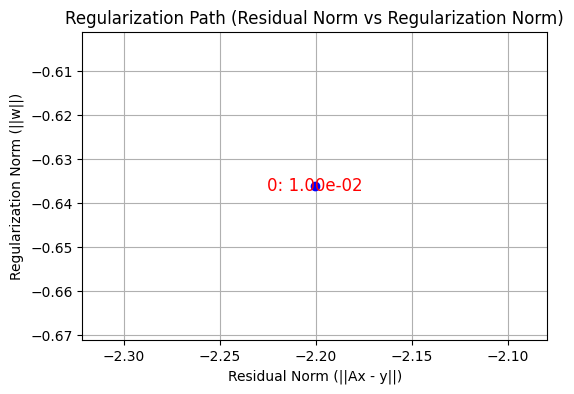

第 1 次迭代的train误差：
S_l_inf= 0.20182044365822982 S_L_2= 0.009123444338979873 S_l_2= 0.03713464359423004
第 1 次迭代的泛化误差：


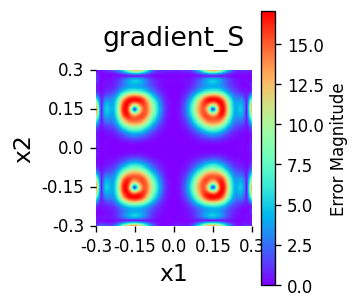

S_l_inf= 0.39062522149669376 S_L_2= 0.013381869146350528 S_l_2= 0.055665152645173285


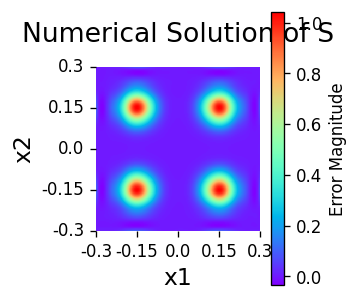

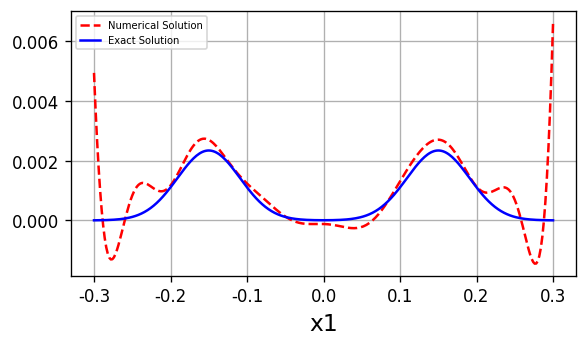

第 1 次自适应网格细分...
S_l_inf= 0.20182044365822982 S_L_2= 0.009123444338979873 S_l_2= 0.03713464359423004
S_l_inf= 0.2001585510657797 S_L_2= 0.012511666976001201 S_l_2= 0.05187227850321094
Generating visualizations...
1. Plotting mesh comparison...


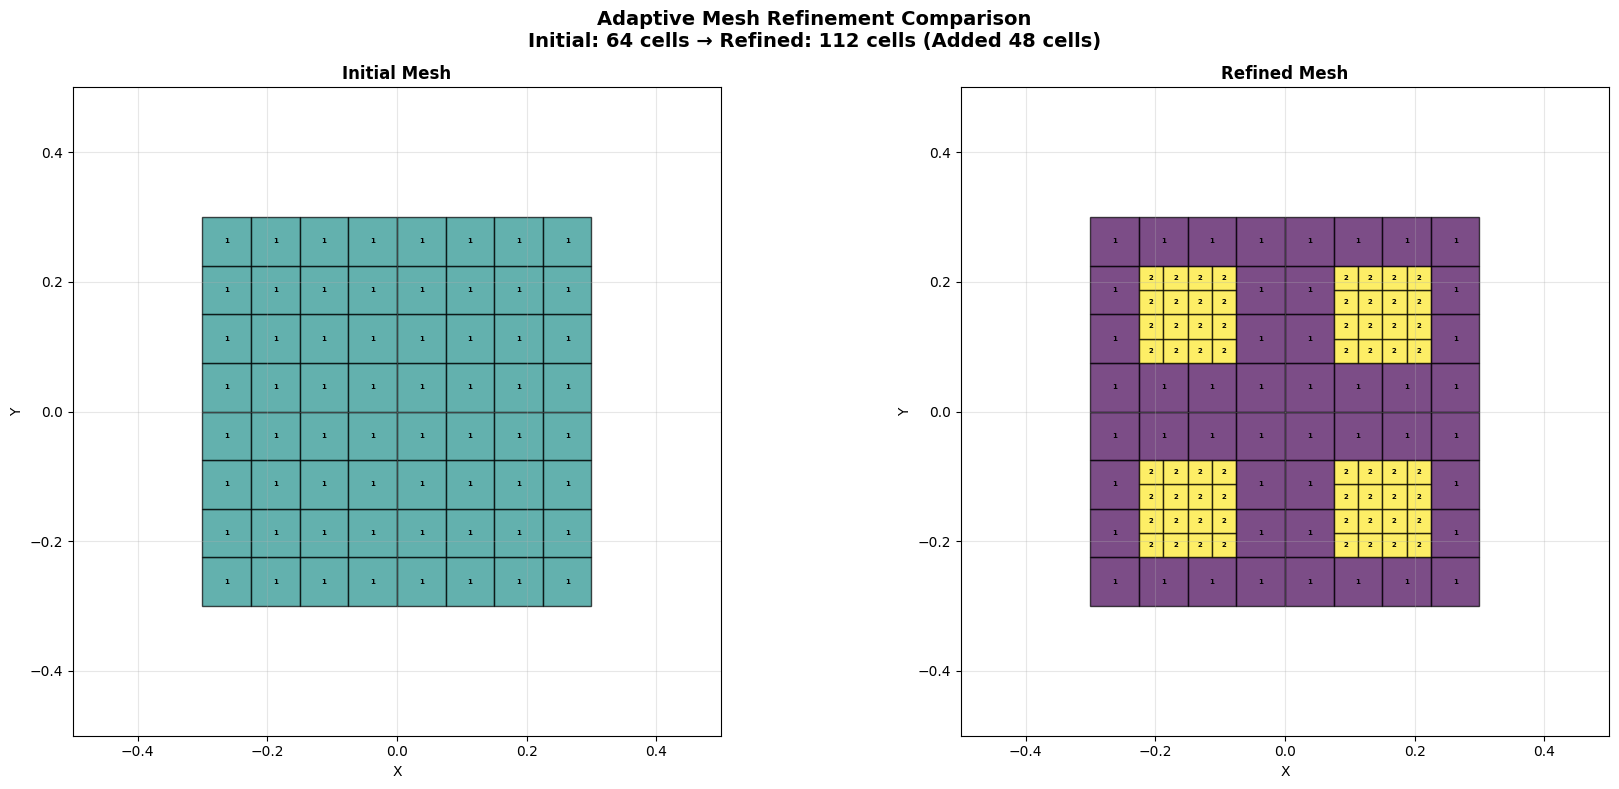

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


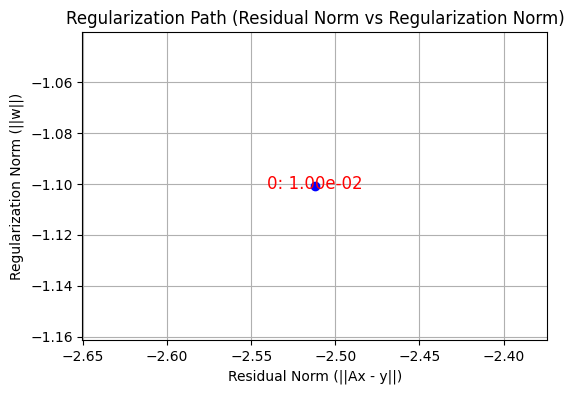

第 2 次迭代的train误差：
S_l_inf= 0.009822851800574338 S_L_2= 0.0015042903435449116 S_l_2= 0.004155858813565078
第 2 次迭代的泛化误差：


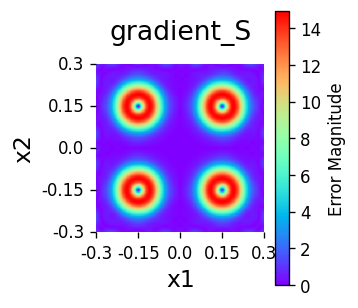

S_l_inf= 0.052095800510530164 S_L_2= 0.0016161123712018204 S_l_2= 0.006722614072133285


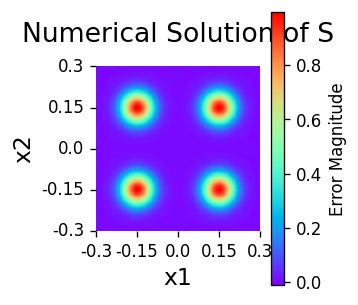

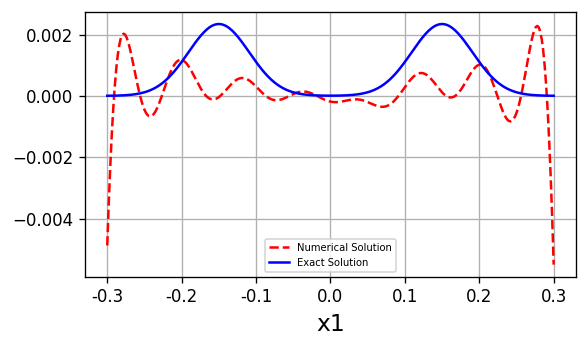

第 2 次自适应网格细分...
S_l_inf= 0.009822851800574338 S_L_2= 0.0015042903435449116 S_l_2= 0.004155858813565078
S_l_inf= 0.01711797833722712 S_L_2= 0.001540527110722053 S_l_2= 0.004254579875840474
Generating visualizations...
1. Plotting mesh comparison...


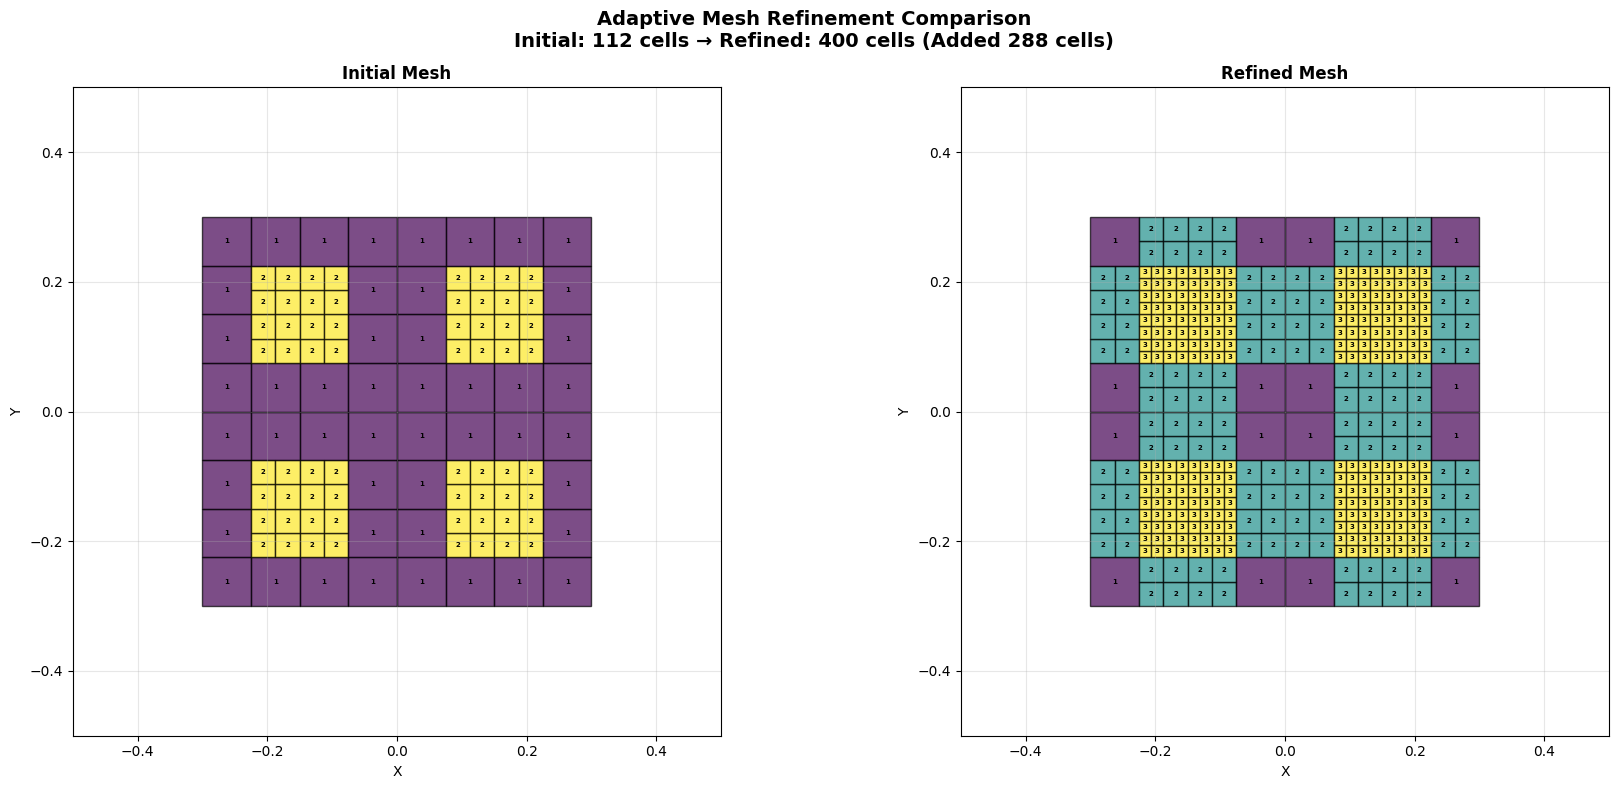

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


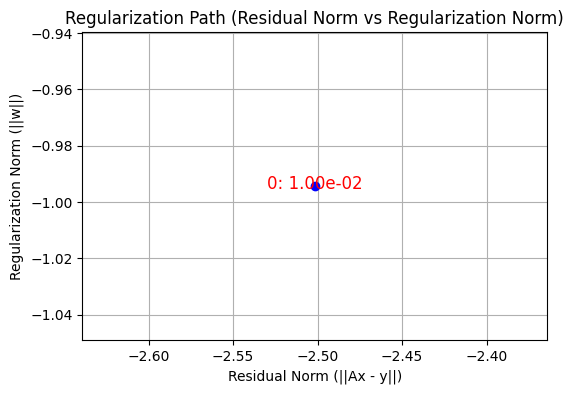

第 3 次迭代的train误差：
S_l_inf= 0.007886690443229727 S_L_2= 0.0008193846982425856 S_l_2= 0.0021383078742092903
第 3 次迭代的泛化误差：


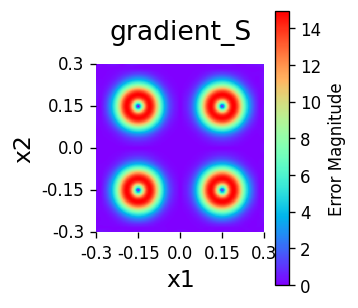

S_l_inf= 0.013101580998618387 S_L_2= 0.0006953755484283726 S_l_2= 0.002892584408475019


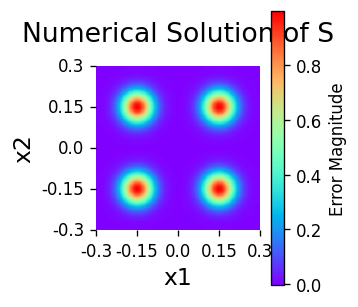

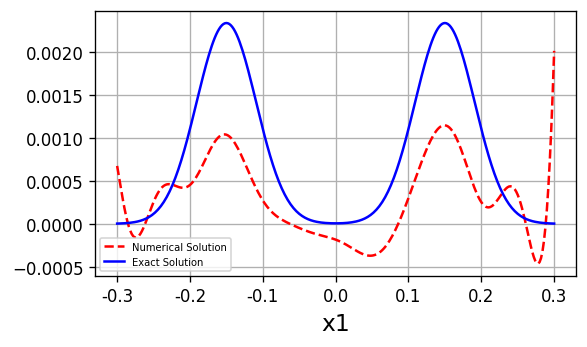

第 3 次自适应网格细分...
S_l_inf= 0.007886690443229727 S_L_2= 0.0008193846982425856 S_l_2= 0.0021383078742092903
S_l_inf= 0.008013429390046746 S_L_2= 0.0008089776631584101 S_l_2= 0.002111075120631969
Generating visualizations...
1. Plotting mesh comparison...


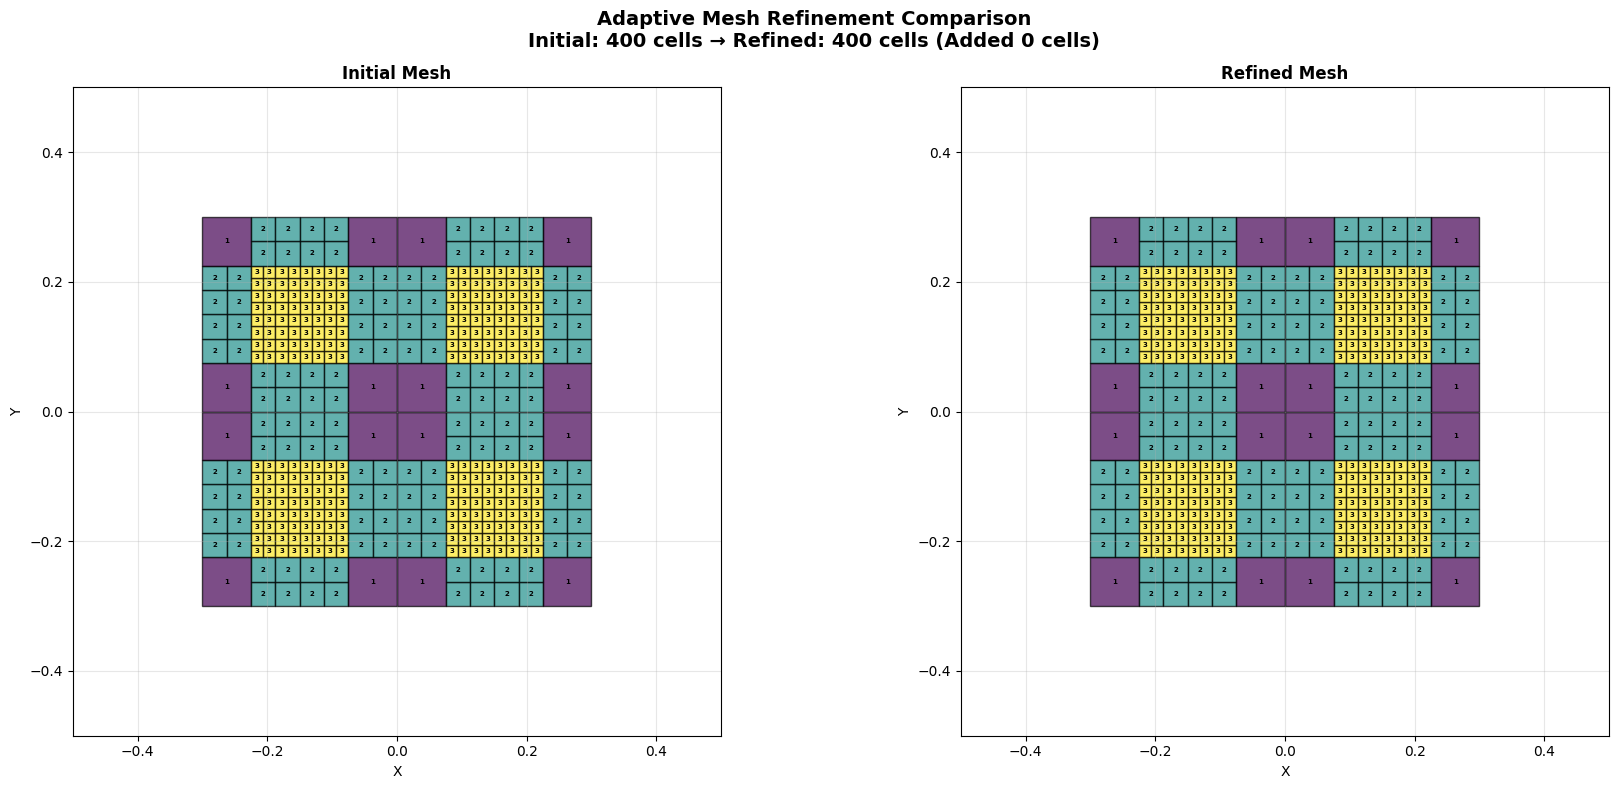

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


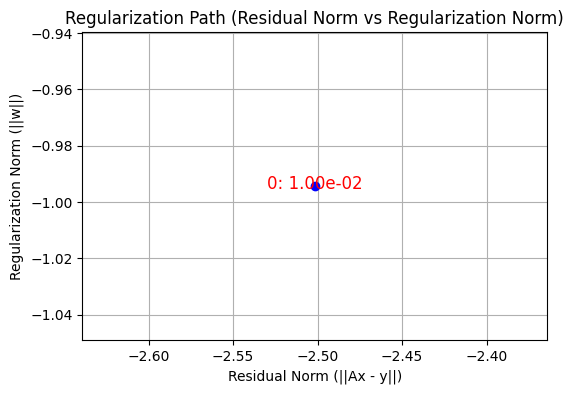

第 4 次迭代的train误差：
S_l_inf= 0.007886690443229727 S_L_2= 0.0008193846982425856 S_l_2= 0.0021383078742092903
第 4 次迭代的泛化误差：


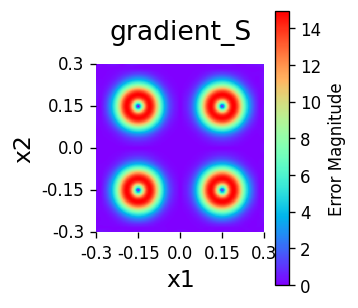

S_l_inf= 0.013101580998618387 S_L_2= 0.0006953755484283726 S_l_2= 0.002892584408475019


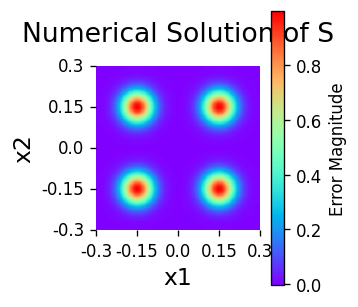

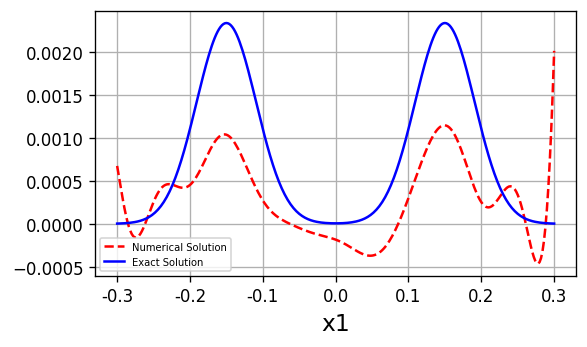

在第 4 次迭代结束


In [10]:
iter_int= 5
Ix,Iy=5,5  #x方向网格点
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-2,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="sin"
refine_threshold_S=[1e-4, 5e-4, 1e-4, 5e-4, 1e-3] #刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-7, 1e-7, 8e-7, 8e-7, 8e-7] #刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-8, 1e-8, 1e-7, 1e-7, 1e-6] #刚开始阈值小多细分，后面阈值大少细分
refine_threshold_grad=[5e-9, 1e-8, 5e-8, 1e-7, 5e-7]
refine_threshold_noise=[1e-2,1e-2,1e-2,1e-2,1e-2,1e-2]
# using main_fix.ada_int_fix
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_num_store,S_l2=main_fix.ada_int(iter_int,delta,cells,nx,models0,M,af,kk,F_1,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)

In [5]:
point_number[-1]

3600

In [14]:
# 保存 models1 模型
torch.save(models0,f"./results/pi/models0_33_3200_{point_number[-1]}_10-4.pth")


In [15]:
np.save("./results/pi/S_num_store",S_num_store)


In [16]:
import pickle # 导入 pickle 模块
output_pickle_file = "./results/pi/cells_store_last.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(cells_store[-1], f)